**PRiAD sprawdzian**

# Sprawdzian z Podstaw Reprezentacji i Analizy Danych - GR 3 (Czw. 10-12)

**Instrukcja ogólna**

1. Uzupełnij swoje dane osobowe (imię, nazwisko, numer indeksu) w pierwszej komórce kodu.
2. Nie zmieniaj kodu oznaczonego komentarzem `# TEGO KODU NIE ZMIENIAJ`.
3. Wypełniaj kod wyłącznie w komórkach oznaczonych komentarzem **`TU NAPISZ SWÓJ KOD`**.
4. Wszystkie wyniki liczbowe wpisuj do odpowiednich pól słownika `results`.
5. Na końcu uruchom komórkę zapisującą `results` do pliku CSV.

Maksymalna liczba punktów: **20**

- Zadanie 1 – Analiza eksploracyjna (EDA): **5 pkt**  
- Zadanie 2 – Wizualizacja i wnioski: **5 pkt** (ocena ręczna)  
- Zadanie 3 – Klasyfikacja: **5 pkt**  
- Zadanie 4 – Grupowanie: **5 pkt**



In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score  # w tym notatniku już nie używany, ale może być zaimportowany


In [71]:
# ======================
# DANE STUDENTA – UZUPEŁNIJ
# ======================

imie = "Szymon"          # <-- wpisz swoje imię (string)
nazwisko = "Bereza"  # <-- wpisz swoje nazwisko (string)
indeks = 337542        # <-- wpisz swój 6-cyfrowy numer indeksu (int)


In [72]:
# ======================
# TEGO KODU NIE ZMIENIAJ
# ======================


np.random.seed(indeks)
pakiet_filename = f"pakiet_{indeks}.csv"
df = pd.read_csv(pakiet_filename)
print("\nPodgląd danych:")
df




Podgląd danych:


,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,class
0,14.655848,3316.440542,-15.401250,0.012419,3.658845,-0.730093,544.342947,15.938908,4
1,-28.398295,10370.010215,-31.365968,0.015021,4.952143,-0.330325,1246.355313,4.039824,4
2,15.766848,-70.259765,-22.581707,0.025726,3.913766,-0.380667,447.936744,13.919277,4
3,nan,-3774.588590,-43.056706,0.002171,2.553186,-0.552148,1513.140398,1.032319,2
4,-6.101534,-3443.854093,-22.312134,0.109445,1.848505,-0.137327,nan,5.598579,3
...,...,...,...,...,...,...,...,...,...
421,nan,-7105.342064,-59.408471,nan,6.919985,-0.272980,262.426548,-21.547271,1
422,4.526020,-6390.321278,-65.324039,0.025924,5.395305,-0.227294,nan,-17.791306,1
423,-21.239861,6233.868052,-30.651400,0.028966,5.741536,-0.175645,1393.939234,nan,4
424,nan,-2050.682606,-23.398665,0.119841,1.906370,-0.261941,293.505197,17.785740,0


In [73]:
# ======================
# STRUKTURA WYNIKÓW – TEGO KODU NIE ZMIENIAJ
# ======================

results = {
    "imie": imie,
    "nazwisko": nazwisko,
    "indeks": indeks,
    
    # EDA – 10 wartości
    "eda_num_rows": None,
    "eda_num_attributes": None,
    "eda_total_missing": None,
    "eda_num_rows_with_missing": None,
    "eda_num_column_with_missing": None,
    "eda_num_classes": None,

    # Klasyfikacja – Najbliższy prototyp (różny dystans) (NearestCentroid) + drugi klasyfikator Gaussian Naive Bayes (GaussianNB)
    "cls_np_euclidean_accuracy": None,
    "cls_np_manhattan_accuracy": None,
    "cls_np_best_accuracy": None,

    "cls_gauss_accuracy": None,


    # Grupowanie – Hierarchiczne grupowanie aglomeratycjne, średnie odległości do hipotetycznych centroidów dla k=2..5
    "clu_agglomerative_mean_dist_k2": None,
    "clu_agglomerative_mean_dist_k3": None,
    "clu_agglomerative_mean_dist_k4": None,
    "clu_agglomerative_mean_dist_k5": None
}  

results


{'imie': 'Szymon',
 'nazwisko': 'Bereza',
 'indeks': 337542,
 'eda_num_rows': None,
 'eda_num_attributes': None,
 'eda_total_missing': None,
 'eda_num_rows_with_missing': None,
 'eda_num_column_with_missing': None,
 'eda_num_classes': None,
 'cls_np_euclidean_accuracy': None,
 'cls_np_manhattan_accuracy': None,
 'cls_np_best_accuracy': None,
 'cls_gauss_accuracy': None,
 'clu_agglomerative_mean_dist_k2': None,
 'clu_agglomerative_mean_dist_k3': None,
 'clu_agglomerative_mean_dist_k4': None,
 'clu_agglomerative_mean_dist_k5': None}

## Zadanie 1 (5 pkt) – Analiza eksploracyjna i statystyki opisowe

Dany jest zbiór danych zawierający atrybuty opisowe (`attr1`, `attr2`, …) oraz
atrybut decyzyjny `class`.

**Wykonaj następujące działania:**

1. Ustal:
   1. liczbę obserwacji (wierszy) w zbiorze,
   2. liczbę atrybutów **opisujących** (bez kolumny `class`).


2. Zbadaj braki danych:
   1. wyznacz łączną liczbę braków (`NaN`) w całym zbiorze,
   2. wyznacz liczbę wierszy zawierających co najmniej jeden brak danych,
   3. dla każdej kolumny policz liczbę braków i wskaż nazwę kolumny,
      w której braków jest najwięcej.


3. Ustal liczbę różnych klas w atrybucie `class`.


4. Dla wszystkich atrybutów opisowych (bez `class`) oblicz:
   - rozstęp (max – min),
   - rozstęp międzykwartylowy (IQR = Q3 – Q1),
   - wariancję,
   - średnią.




**Wyniki liczbowe wpisz do pól słownika `results`:**

- `eda_num_rows`             - liczba obiektów
- `eda_num_attributes`       - liczba atrybutów 
- `eda_total_missing`        - liczba braków
- `eda_num_rows_with_missing`- liczba wierszy zawierających co najmniej 1 brak
- `eda_num_column_with_missing`  - liczba kolumn zawierających co najmniej 1 brak
- `eda_num_classes`          - kolumna o największej liczbie braków



In [74]:
# ----------------------
# ZADANIE 1 – ANALIZA EKSPLORACYJNA
# TU NAPISZ SWÓJ KOD
# ----------------------


# 1) Liczba obserwacji i liczba atrybutów opisujących (bez 'class')
eda_num_rows = df.shape[0]
eda_num_attributes = len(df.iloc[0, :-1])


# 2) Braki danych
eda_total_missing = df.isna().sum().sum()
eda_num_rows_with_missing = df.isna().any(axis=1).sum()

nans_per_col = df.isna().sum().sort_values(ascending=False)
col_most_nans = nans_per_col.idxmax() if len(nans_per_col) > 0 else None

eda_num_classes = df.iloc[:, -1].nunique()

if len(numeric_cols) == 0:
    print("Brak atrybutów numerycznych do analizy.")
else:
    stats = []
    for col in numeric_cols:
        col_series = df[col].dropna()
        if col_series.empty:
            rng = np.nan
            iqr = np.nan
            var = np.nan
            mean = np.nan
        else:
            rng = col_series.max() - col_series.min()
            q1 = col_series.quantile(0.25)
            q3 = col_series.quantile(0.75)
            iqr = q3 - q1
            var = col_series.var(ddof=1)   # wariancja próbki; użyj ddof=0 dla wariancji populacji
            mean = col_series.mean()
        stats.append({
            "attribute": col,
            "range": rng,
            "IQR": iqr,
            "variance": var,
            "mean": mean
        })

    stats_df = pd.DataFrame(stats).set_index("attribute")
    pd.set_option('display.float_format', lambda x: f"{x:.6f}")
    print("\nStatystyki dla atrybutów numerycznych (bez 'class'):")
    print(stats_df)



# 1. Utwórz listę atrybutów opisujących (bez 'class'), np.:
#
# 2. Oblicz:
#
# 3. Braki danych:

# 4. Liczba klas w 'class':
#
# 5. Statystyki opisowe dla atrybutów opisowych:
#
#





Statystyki dla atrybutów numerycznych (bez 'class'):
                 range          IQR        variance         mean
attribute                                                       
attr1       263.004214    49.951604     1548.638500    -2.898903
attr2     48127.483243 10112.984886 59468918.427624 -3255.948539
attr3        94.250116    26.464945      319.527884   -30.864393
attr4         0.164788     0.092999        0.002324     0.058873
attr5         8.169007     2.399736        2.451773     3.212037
attr6         1.011684     0.283557        0.040985    -0.382051
attr7      4530.076443   989.489962   588685.081411   484.207645
attr8        71.252341    14.423338      121.921442    10.112472
class         4.000000     2.000000        1.624700     2.502347


In [75]:
# 6. Na końcu wpisz wszystkie wyliczone wartości do 'results'
#    results["eda_num_rows"] = ...
#    TEN FRAGMENT KODU MASZ GOTOWY PONIŻEJ - WYSTARCZY ZAMIENIĆ
#     'None' W KAŻDEJ LINIJCE NA TWÓJ KOD

results["eda_num_rows"] = eda_num_rows
results["eda_num_attributes"] = eda_num_attributes
results["eda_total_missing"] = eda_total_missing
results["eda_num_rows_with_missing"] = eda_num_rows_with_missing
results["eda_num_column_with_missing"] = eda_num_column_with_missing
results["eda_num_classes"] = eda_num_classes

# sprawdzenie wartości

print("Wyniki EDA:")
for k in results:
    if k.startswith("eda_"):
        print(k, "=", results[k])

Wyniki EDA:
eda_num_rows = 426
eda_num_attributes = 8
eda_total_missing = 321
eda_num_rows_with_missing = 233
eda_num_column_with_missing = 8
eda_num_classes = 5


## Zadanie 2 (5 pkt) – Wizualizacja danych i wnioski

Na podstawie zbioru danych wykonaj następujące wizualizacje:

1. **Histogramy** wybranych atrybutów opisowych (co najmniej 3 atrybuty).
2. **Wykresy pudełkowe (boxplot)** dla kilku atrybutów (co najmniej 3, różniące się od siebie),
   w tym przynajmniej jeden wykres pokazujący rozkład wartości atrybutu w podziale na klasy `class`.
3. **Macierz wykresów punktowych** zawierającą wykresy punktowe wszystkich par atrybutów
4. **Wykresy punktowe (scatter plot)** prezentujące zależność pomiędzy
   wybranymi parami atrybutów (co najmniej 4 wykresy), z zaznaczeniem klas
   (np. kolorem), wykresy powinny pokazywać atrybuty dla których jest łatwo i trudno rozróżnić klasy, oraz o silnej i słabej korelacji


W osobnej komórce tekstowej (Markdown) sformułuj **wnioski z wizualizacji**:
1. jak oceniasz zmienność i rozproszenie poszczególnych atrybutów.
2. czy i gdzie widać wartości odstające (outliers),
3. czy rozkłady są w przybliżeniu symetryczne, czy wyraźnie skośne,
4. które atrybuty są silnie, a które słabo skorelowane,
5. które atrybuty wydają się dobrze rozróżniać klasy,
6. czy atrybuty mają bardzo różne skale (różne rzędy wielkości)
   i czy dane wymagają normalizacji/standaryzacji przed klasyfikacją i grupowaniem

UWAGA: W każdym wniosku wskaż wykres, na podstawie którego go sformułowałeś !

Ta część jest oceniana **ręcznie** (5 pkt).  
W tej części **nie zmieniasz** słownika `results`.


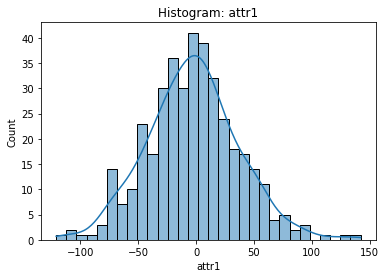

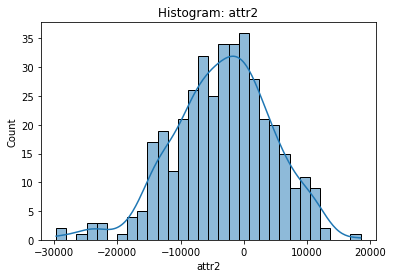

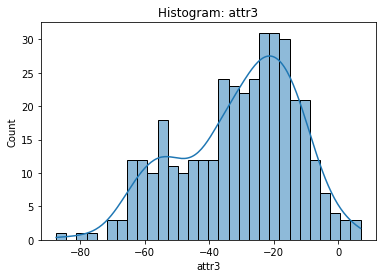

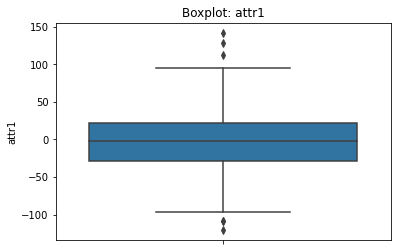

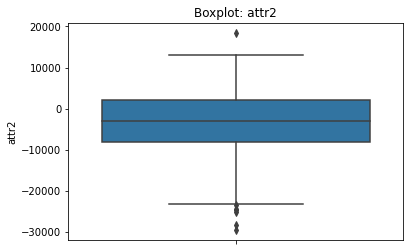

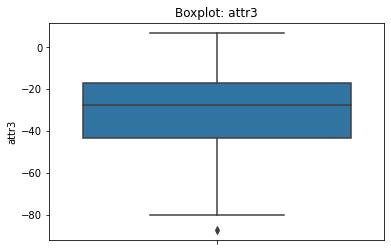

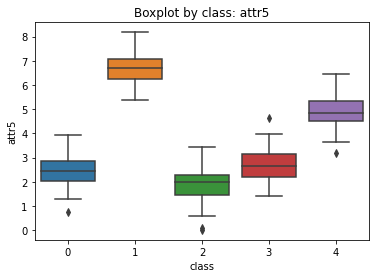

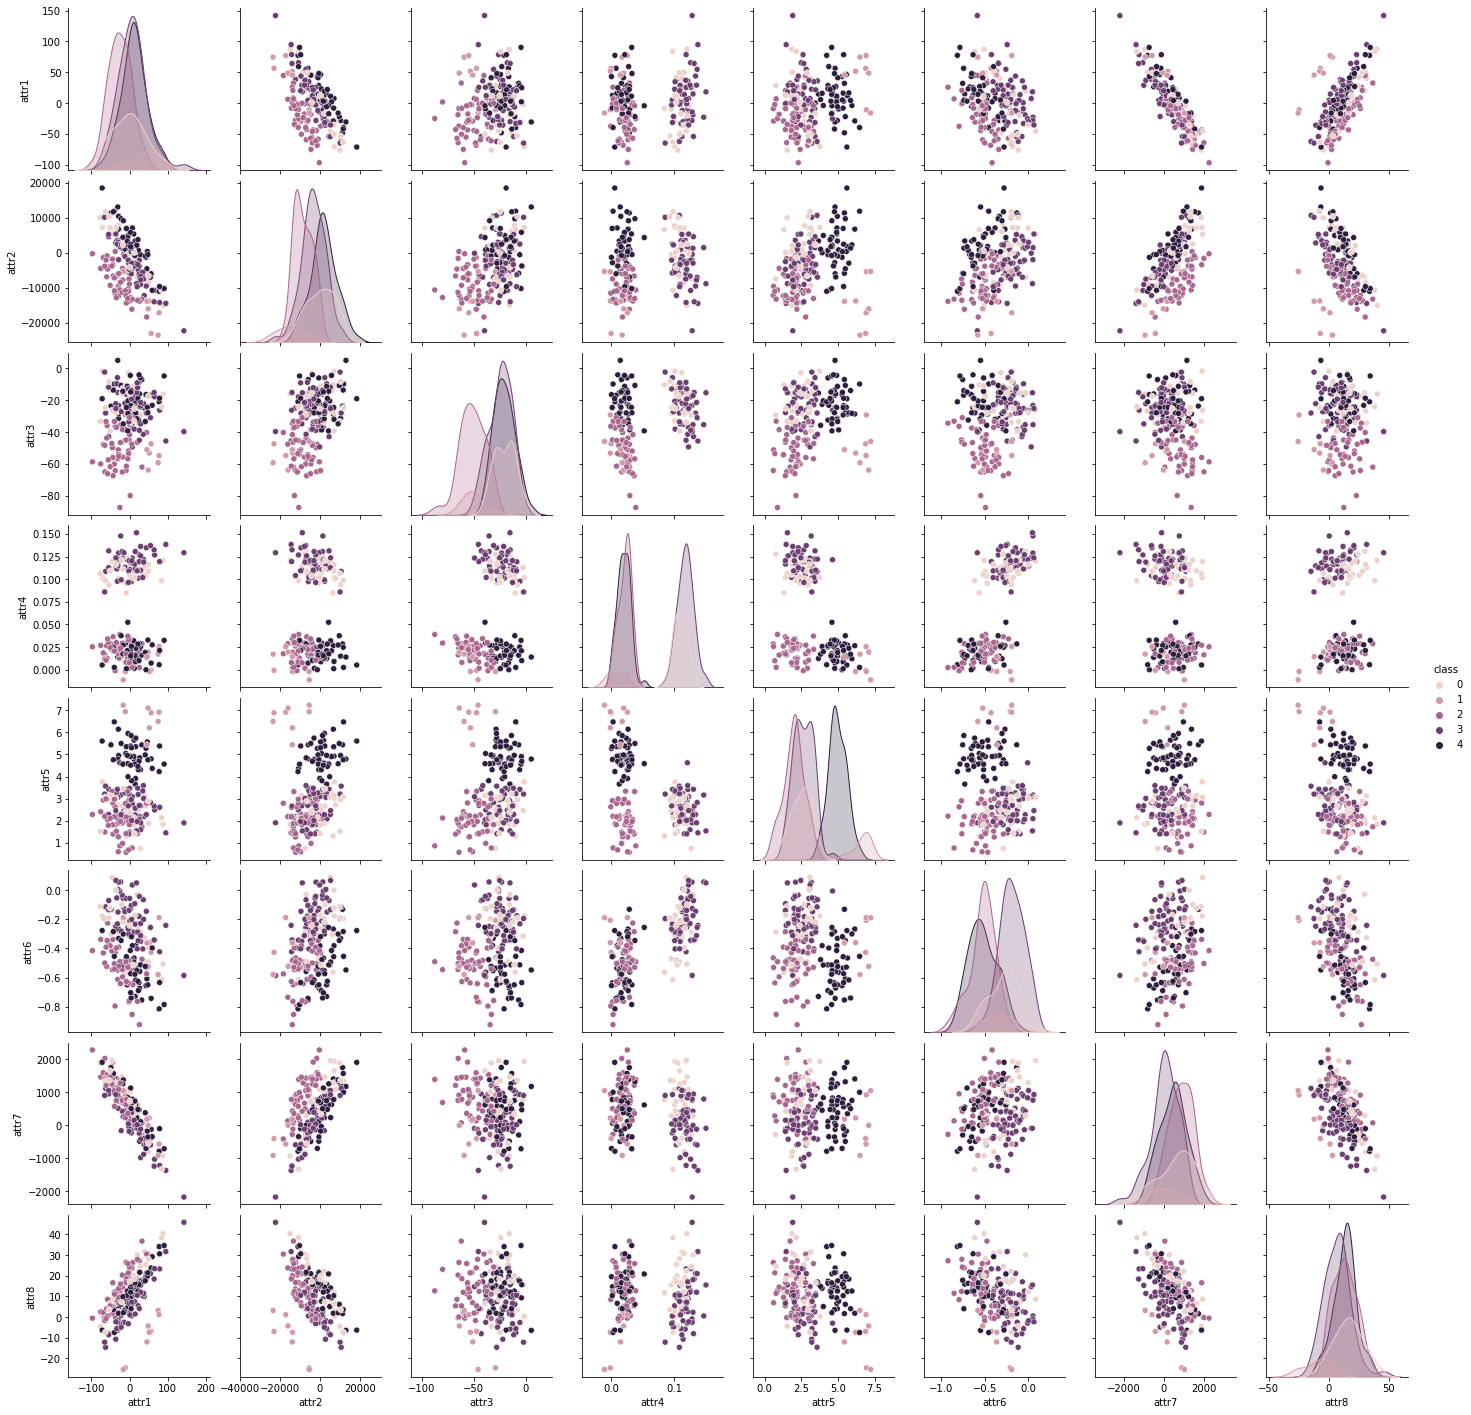

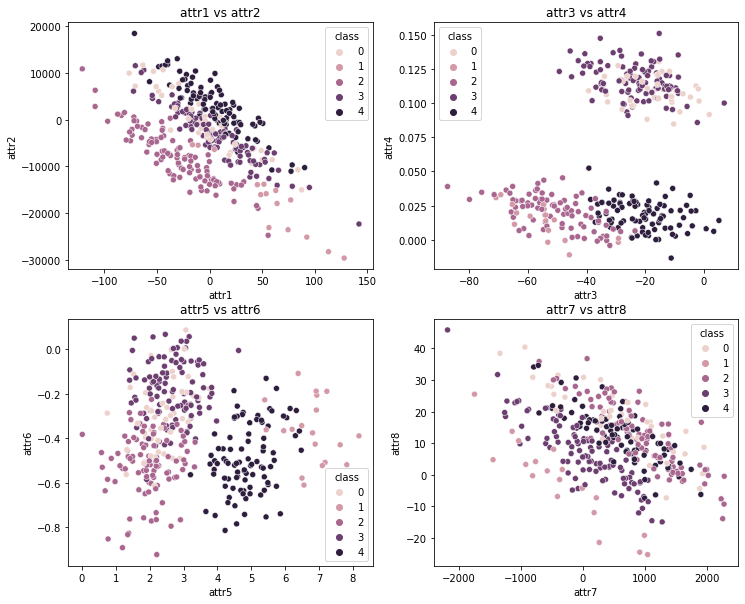

<AxesSubplot:>

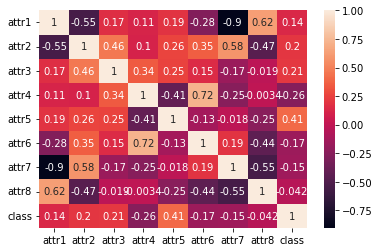

In [64]:
# ----------------------
# ZADANIE 2 – WIZUALIZACJE
# TU NAPISZ SWÓJ KOD
# ----------------------
plt.figure(figsize=(6,4)) 
sns.histplot(df['attr1'], bins=30, kde=True) 
plt.title(f"Histogram: attr1") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.histplot(df['attr2'], bins=30, kde=True) 
plt.title(f"Histogram: attr2") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.histplot(df['attr3'], bins=30, kde=True) 
plt.title(f"Histogram: attr3") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.boxplot(y=df['attr1']) 
plt.title(f"Boxplot: attr1") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.boxplot(y=df['attr2']) 
plt.title(f"Boxplot: attr2") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.boxplot(y=df['attr3']) 
plt.title(f"Boxplot: attr3") 
plt.show()

plt.figure(figsize=(6,4)) 
sns.boxplot(x=df['class'], y=df['attr5']) 
plt.title(f"Boxplot by class: attr5") 
plt.show()

sns.pairplot(data = df.dropna(), hue = 'class', kind = 'scatter')
plt.show()

pairs = [ ("attr1", "attr2"), ("attr3", "attr4"), ("attr5", "attr6"), ("attr7", "attr8") ]

fig, axes = plt.subplots(2,2, figsize=(12,10)) 
axes = axes.flatten() 
for ax, (x,y) in zip(axes, pairs): 
    sns.scatterplot(data=df, x=x, y=y, hue=class_col, ax=ax) 
    ax.set_title(f"{x} vs {y}")
plt.show()
dff = df.copy()
dff = dff.dropna()
sns.heatmap(dff.corr(),annot = dff.corr())
# Wskazówki (nie są obowiązkowe, możesz użyć własnych rozwiązań):
#
# 1. Histogramy:
#
# 2. Wykresy pudełkowe:
#
# 3. Macierz wykresów punktowych:
#
# 4. Wybrane wykresy punktowe:
#
# W TEJ CZĘŚCI NIE WYPEŁNIASZ 'results'.


### Wnioski z wizualizacji

*(W tej komórce opisz swoje wnioski z wykonanych wykresów, zgodnie z treścią Zadania 2)*

1. (zmienność i rozproszenie)
zadna z klas nie wykazuje szczegolnej zmiennosci, histogramy są dosyc zwięzłe

2. (wartości odstające)
atrybuty są dosyc zwiezle, jednak dla atrybutu 1 mozna zaobserwowac pewne jednostki odstające od grupy

3. (symetria rozkładów)
sa symetryczne
4. (korelacja) (heatmapa)
(atrybuty 1 oraz 7 mają wysoką korelacje ujemną, natomiast 4 i 6 dosc wysoką korelacje dodatnią)

5. (rozróżnialność klas)(macierz wykresow punktowych)
dobrym rozroznikiem klas moze byc atrybut 4 ze wzgledu na swoj histogram widoczny na macierzy wykresow punktowych, wyroznia klasę 2

6. (skale)(boxplot/histogramy klas)
atrybuty 2 oraz 7 maja zdecydowanie wiekszą skalę w porownaniu do reszty, wymagana jest zatem normalizacja tych atrybutow


## Zadanie 3 (5 pkt) – Klasyfikacja

Wykonaj klasyfikację przy użyciu klasyfikatora Najbliższego Prototypu (Nearest Centroid) dla dystnsów {"euclidean", "manhattan"}

**Wykonaj:**

1. Usuń z danych **wszystkie wiersze zawierające braki** (NaN),
   
2. Wykonaj standaryzację wartości atrybutów opisujących.

2. Zbuduj:
   - macierz cech `X` – wszystkie atrybuty opisowe (bez `class`),
   - wektor etykiet `y` – wartości kolumny `class`.

3. Dokonaj podziału na zbiór uczący i testowy w stosunku 70/30 (30% danych w zbiorze testowym)

4. Dla metric ∈ {"euclidean", "manhattan"} zbuduj klasyfikatory NP
   Oblicz dokładność (accuracy) na zbiorze testowym dla każdego metric.

5. Wyznacz najlepsze `metric` (takie, dla którego klasyfikator wykazuje najwyższą dokładność).



**Wpisz wyniki do słownika `results`:**

- `cls_np_euclidean_accuracy` - dokładność dla metryki euclidean
- `cls_np_manhattan_accuracy` - dokładność dla metryki manhattan
- `cls_np_best_metric` - najlepsza metryka
- `cls_np_best_accuracy` - najwyższa dokładność spośród metryk
- `cls_gauss_accuracy` - dokładność dla Gaussian Naive Bayes classifier 




In [76]:
# ----------------------
# ZADANIE 3 – KLASYFIKACJA
# TU NAPISZ SWÓJ KOD
# ----------------------

# Wskazówki:
#
# 1. Usuń wiersze z brakami:
df = df.dropna()
# 2. Zdefiniuj listę atrybutów opisujących:
X = df.drop(columns=['class']) 
y = df['class']   
# 3. Utwórz macierze wartości atrybutów opisujących X i atrybutu decyzyjnego y


# 4. Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Podział na zbiór uczący i testowy (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)



# 6. Nearest Centroid - euclidean
clf_euclidean = NearestCentroid(metric='euclidean')
clf_euclidean.fit(X_train, y_train)
acc_euclidean = clf_euclidean.score(X_test, y_test)

# 7. Nearest Centroid - manhattan
clf_manhattan = NearestCentroid(metric='manhattan')
clf_manhattan.fit(X_train, y_train)
acc_manhattan = clf_manhattan.score(X_test, y_test)

# 8. Najlepsza metryka
if acc_euclidean >= acc_manhattan:
    best_metric = 'euclidean'
    best_acc = acc_euclidean
else:
    best_metric = 'manhattan'
    best_acc = acc_manhattan

# 9. Gaussian Naive Bayes
clf_gauss = GaussianNB()
clf_gauss.fit(X_train, y_train)
acc_gauss = clf_gauss.score(X_test, y_test)


# 4. Podziel dane na zbiór uczący i testowy w stosunku 70/30 (30% danych w zbiorze testowym)
#    
# 5. Dla k w [1, 5, 9, 11]: utwórz model klasyfikatora, policz dokładność na zbiorze testowym
#
# 6. Znajdź najlepsze k
#  

{'imie': 'Szymon', 'nazwisko': 'Bereza', 'indeks': 337542, 'eda_num_rows': 426, 'eda_num_attributes': 8, 'eda_total_missing': 321, 'eda_num_rows_with_missing': 233, 'eda_num_column_with_missing': 8, 'eda_num_classes': 5, 'cls_np_euclidean_accuracy': None, 'cls_np_manhattan_accuracy': None, 'cls_np_best_accuracy': None, 'cls_gauss_accuracy': None, 'clu_agglomerative_mean_dist_k2': None, 'clu_agglomerative_mean_dist_k3': None, 'clu_agglomerative_mean_dist_k4': None, 'clu_agglomerative_mean_dist_k5': None}


In [66]:
# 9. Na końcu wpisz wszystkie wyliczone wartości do 'results'
#    results["cls_knn_k3_accuracy"] = ...
#    TEN FRAGMENT KODU MASZ GOTOWY PONIŻEJ - WYSTARCZY ZAMIENIĆ
#     'None' W KAŻDEJ LINIJCE NA TWÓJ KOD

results["cls_np_euclidean_accuracy"] = acc_euclidean
results["cls_np_manhattan_accuracy"] = acc_manhattan
results["cls_np_best_metric"] = best_metric
results["cls_np_best_accuracy"] = best_acc
results["cls_gauss_accuracy"] = acc_gauss


# sprawdzenie wartości

print("Wyniki CLS:")
for k in results:
    if k.startswith("cls_"):
        print(k, "=", results[k])

Wyniki CLS:
cls_np_euclidean_accuracy = 1.0
cls_np_manhattan_accuracy = 0.9482758620689655
cls_np_best_accuracy = 1.0
cls_gauss_accuracy = 0.9310344827586207
cls_np_best_metric = euclidean


## Zadanie 4 (5 pkt) – Grupowanie metodą hierarchiczego grupowania aglomeracyjnego (AgglomerativeClustering)

W tym zadaniu analizujemy jakość grupowania metodą **hierarchiczego grupowania aglomeracyjnego** (AgglomerativeClustering)
dla różnych liczności grup.

**Wykonaj:**

1. Użyj danych **po usunięciu wierszy z brakami** .

2. Zbuduj:
   - macierz cech `X_clu` – atrybuty opisujące (wszystkie kolumny oprócz `class`),
   - wektor klas `y_clu` – kolumna `class` (może być użyty jedynie pomocniczo
     do własnej analizy, nie wchodzi do wyników automatycznych).

3. Zastosuj standaryzację cech

4. Dla każdej wartości k z zestawu:
   $
      k \in \{2, 3, 4, 5\}
   $
   wykonaj grupowanie metodą hierarchiczego grupowania aglomeracyjnego.

5. Dla każdego k oblicz **centroid - uśredniony punkt środkowy każdej z powstałych grup** a następnie oblicz **średnią odległość (Euklidesową) obiektów do centroidów, do których są przypisane**.

   Otrzymasz w ten sposób **4 wartości** średnich odległości,
   odpowiadający kolejno k = 2, 3, 4, 5

6. Wpisz te wartości do słownika `results` w polach:

- `clu_agglomerative_mean_dist_k2`   
- `clu_agglomerative_mean_dist_k3`  
- `clu_agglomerative_mean_dist_k4`  
- `clu_agglomerative_mean_dist_k5`  
 

(odpowiednio dla k = 2, 3, 4, 5).


In [77]:
# ----------------------
# ZADANIE 4 – GRUPOWANIE (K-MEANS)
# TU NAPISZ SWÓJ KOD
# ----------------------


# 1. Wczytaj dane
df = pd.read_csv(pakiet_filename)

# 2. Usuń wiersze z brakami
df = df.dropna()

# 3. Macierz cech X_clu i wektor klas y_clu
X_clu = df.drop(columns=['class'])
y_clu = df['class']  # tylko pomocniczo

# 4. Standaryzacja cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clu)

# Funkcja do obliczania średniej odległości do centroidów
def mean_distance_to_centroids(X, labels):
    unique_labels = np.unique(labels)
    centroids = []
    for lab in unique_labels:
        centroids.append(X[labels == lab].mean(axis=0))
    centroids = np.array(centroids)
    dists = []
    for i, lab in enumerate(labels):
        centroid = centroids[lab]
        d = np.linalg.norm(X[i] - centroid)
        dists.append(d)
    return np.mean(dists)

results = {}

# 5. Grupowanie dla k = 2, 3, 4, 5
clu = AgglomerativeClustering(n_clusters=2)
labels = clu.fit_predict(X_scaled)
mean_dist2 = mean_distance_to_centroids(X_scaled, labels)
    
clu = AgglomerativeClustering(n_clusters=3)
labels = clu.fit_predict(X_scaled)
mean_dist3 = mean_distance_to_centroids(X_scaled, labels)
    
clu = AgglomerativeClustering(n_clusters=4)
labels = clu.fit_predict(X_scaled)
mean_dist4 = mean_distance_to_centroids(X_scaled, labels)
    
clu = AgglomerativeClustering(n_clusters=5)
labels = clu.fit_predict(X_scaled)
mean_dist5 = mean_distance_to_centroids(X_scaled, labels)

# Wskazówki:
#
# 1. Upewnij się, że masz pracujesz na właściwym zbiorze danych z Zadania 3:
#
# 2. Utwórz modele grupowania dla kolejnych wartości k
#
# 3. Dla każdego modelu wyznacz średnią odległość od centroidu



In [78]:
# 9. Na końcu wpisz wszystkie wyliczone wartości do 'results'
#    results["clu_kmeans_mean_dist_k2"] = ...
#    TEN FRAGMENT KODU MASZ GOTOWY PONIŻEJ - WYSTARCZY ZAMIENIĆ
#     'None' W KAŻDEJ LINIJCE NA TWÓJ KOD

results["clu_agglomerative_mean_dist_k2"] = mean_dist2
results["clu_agglomerative_mean_dist_k3"] = mean_dist3
results["clu_agglomerative_mean_dist_k4"] = mean_dist4
results["clu_agglomerative_mean_dist_k5"] = mean_dist5


# sprawdzenie wartości

print("Wyniki CLU:")
for k in results:
    if k.startswith("clu_"):
        print(k, "=", results[k])

Wyniki CLU:
clu_agglomerative_mean_dist_k2 = 2.324974871988883
clu_agglomerative_mean_dist_k3 = 2.10183823809435
clu_agglomerative_mean_dist_k4 = 1.7985279799523057
clu_agglomerative_mean_dist_k5 = 1.6921901853815555


In [79]:
# ======================
# ZAPIS WYNIKÓW – TEGO KODU NIE ZMIENIAJ
# ======================

results_df = pd.DataFrame([results])
wyniki_filename = f"wyniki_{indeks}.csv"
wyniki_path = os.path.join(wyniki_filename)

results_df.to_csv(wyniki_path, index=False)
print(f"Zapisano wyniki do pliku: {wyniki_path}")

display(results_df)


Zapisano wyniki do pliku: wyniki_337542.csv


,clu_agglomerative_mean_dist_k2,clu_agglomerative_mean_dist_k3,clu_agglomerative_mean_dist_k4,clu_agglomerative_mean_dist_k5
0,2.324975,2.101838,1.798528,1.692190


In [80]:
results

{'clu_agglomerative_mean_dist_k2': 2.324974871988883,
 'clu_agglomerative_mean_dist_k3': 2.10183823809435,
 'clu_agglomerative_mean_dist_k4': 1.7985279799523057,
 'clu_agglomerative_mean_dist_k5': 1.6921901853815555}

---
Pliki wynikowe wgraj we wskazane przez prowadzącego miejsce